In [52]:
from lib.dds import *
from lib.time import *
from lib.dataplot import *
from lib.system import *
from lib.bug import *
from lib.pot_field import *
from collections import deque
import numpy as np
import cv2
import math
import time

#init plots
PLTS_N = 10
plts = [DataPlotter() for i in range(PLTS_N)]

plts[0] = DataPlotter()
plts[0].set_x("Time ")
plts[0].add_y("pos_z", "Position Z")
plts[0].add_y("target", "target")
plts[1] = DataPlotter()
plts[1].set_x("Time ")
plts[1].add_y("pos_x", "Position X")
plts[1].add_y("target", "target")
plts[2] = DataPlotter()
plts[2].set_x("Time")
plts[2].add_y("ang", "Rotation")
plts[2].add_y("target", "target")
plts[3] = DataPlotter()
plts[3].set_x("Time")
plts[3].add_y("vel_z", "Velocity Z")
plts[4] = DataPlotter()
plts[4].set_x("Time")
plts[4].add_y("vel_x", "Velocity X")
plts[5] = DataPlotter()
plts[5].set_x("Time")
plts[5].add_y("vel_ang", "Rotational Velocity")
plts[6] = DataPlotter()
plts[6].set_x("Time")
plts[6].add_y("w1", "Front Left Motor")
plts[7] = DataPlotter()
plts[7].set_x("Time")
plts[7].add_y("w2", "Front Right Motor")
plts[8] = DataPlotter()
plts[8].set_x("Time")
plts[8].add_y("w3", "Rear Right Motor")
plts[9] = DataPlotter()
plts[9].set_x("Time")
plts[9].add_y("w4", "Rear Left Motor")

dds = DDS()
dds.start()

#subscribe to robot sensors
dds.subscribe(["pos_z", "pos_x", "ang", "vel_z","vel_x","vel_ang", "colliding", "obstacle_pos_z", "obstacle_pos_x"])

#init map
width, height = 1000, 1000
imm = np.zeros((height, width, 3), dtype=np.uint8)
map_scale = 25
center_pixel_z = height // 2
center_pixel_x = width // 2

#init obstacle queue
TTL = 3.0
valid_points = deque()

#set target position
global_target_pos_z = 20
global_target_pos_x = 5
ang_target = 180
dds.publish("target_z", global_target_pos_z, dds.DDS_TYPE_FLOAT)
dds.publish("target_x", global_target_pos_x, dds.DDS_TYPE_FLOAT)
target_pixel_x = global_target_pos_x * map_scale + center_pixel_x
target_pixel_z = global_target_pos_z * map_scale + center_pixel_z

#init controllers
robot = MecanumController(1, 2.5, 0.008, 15, 0.15, 1)
pos_con = PositionController(3, 0, 0, 4)
ori_con = OrientationController(0.1, 0, 0, 3)
pot_field = PotField(0.5, 4, 3, global_target_pos_z, global_target_pos_x) #k_att, k_rep, rho_0
bug = Bug(1, 2.1, 3)
bugging = False

#read sensors
pos_z = dds.wait("pos_z")
pos_x = dds.wait("pos_x")
ang = dds.wait("ang")

t = Time()
t.start()

while math.hypot(global_target_pos_z - pos_z, global_target_pos_x - pos_x) > 0.05 or abs(ang_target - ang) > 0.3:
    delta_t = t.elapsed()
    now = time.time()

    #read sensors
    pos_z = dds.wait("pos_z")
    pos_x = dds.wait("pos_x")
    ang = dds.wait("ang")
    lin_vel_z = dds.wait("vel_z")
    lin_vel_x = dds.wait("vel_x")
    ang_vel = dds.wait("vel_ang")
    is_colliding = dds.read("colliding")

    #append new obstacles
    if is_colliding:
        obstacle_pos_z = dds.read("obstacle_pos_z")
        obstacle_pos_x = dds.read("obstacle_pos_x")
        bug.add_point([pos_z, pos_x], [obstacle_pos_z, obstacle_pos_x])
        valid_points.append((now + TTL, obstacle_pos_x, obstacle_pos_z, (0, 0, 255)))

    #pop expired points
    valid_points = [p for p in valid_points if p[0] >= now]

    #check if robot should be bugging
    if abs(lin_vel_z) < 0.15 and abs(lin_vel_x) < 0.15 and t.get() > 2 and (not bugging) and math.hypot(pos_x - global_target_pos_x, pos_z - global_target_pos_z) > 2:
        bug.start([pos_z, pos_x], [global_target_pos_z, global_target_pos_x])
        bugging = True

    bug.clear_flag()

    #temporary target
    if math.hypot(global_target_pos_z - pos_z, global_target_pos_x - pos_x) < 0.5: #if close, snap tmp target to final target
        global_tmp_target_pos_z = global_target_pos_z
        global_tmp_target_pos_x = global_target_pos_x
    elif bugging:
        bugging, global_tmp_target_pos_z, global_tmp_target_pos_x = bug.detour([pos_z, pos_x])
        dds.publish("path_type", 1, dds.DDS_TYPE_INT)
    else:
        global_tmp_target_pos_z, global_tmp_target_pos_x = pot_field.evaluate(pos_z, pos_x, valid_points)
        dds.publish("path_type", 0, dds.DDS_TYPE_INT)

    dds.publish("tmp_target_z", global_tmp_target_pos_z, dds.DDS_TYPE_FLOAT)
    dds.publish("tmp_target_x", global_tmp_target_pos_x, dds.DDS_TYPE_FLOAT)

    #conversion to pixel coordinates
    tmp_target_pixel_z = int(global_tmp_target_pos_z * map_scale) + center_pixel_z
    tmp_target_pixel_x = int(global_tmp_target_pos_x * map_scale) + center_pixel_x
    robot_pixel_z = int(pos_z * map_scale) + center_pixel_z
    robot_pixel_x = int(pos_x * map_scale) + center_pixel_x

    #print points
    imm.fill(0)
    cv2.arrowedLine(imm, (robot_pixel_x, robot_pixel_z), (tmp_target_pixel_x, tmp_target_pixel_z), (0, 255, 0), 3)
    for expire, x, z, color in valid_points:
        cv2.circle(imm, (int(x * map_scale) + center_pixel_x, int(z * map_scale) + center_pixel_z), 2, color, -1)
    cv2.imshow("map", imm)

    #evaluate engine forces
    global_pos_error = np.array([global_tmp_target_pos_z - pos_z, global_tmp_target_pos_x - pos_x])
    global_lin_vel_target = pos_con.evaluate(delta_t, global_pos_error)
    global_lin_vel = np.array([lin_vel_z, lin_vel_x])
    global_lin_vel_error = global_lin_vel_target - global_lin_vel
    local_lin_vel_error = global_to_local(ang, global_lin_vel_error)

    ang_error = (ang_target - ang + 180) % 360 - 180
    ang_vel_target = ori_con.evaluate(delta_t, ang_error)
    ang_vel_error = ang_vel_target - ang_vel
    vel_error = np.append(local_lin_vel_error, ang_vel_error)

    w = robot.evaluate(delta_t, vel_error)

    #publish engine forces
    dds.publish("w1", w[0], dds.DDS_TYPE_FLOAT)
    dds.publish("w2", w[1], dds.DDS_TYPE_FLOAT)
    dds.publish("w3", w[2], dds.DDS_TYPE_FLOAT)
    dds.publish("w4", w[3], dds.DDS_TYPE_FLOAT)

    #update plots
    plts[0].append_x(t.get())
    plts[0].append_y("pos_z", pos_z)
    plts[0].append_y("target", global_target_pos_z)
    plts[1].append_x(t.get())
    plts[1].append_y("pos_x", pos_x)
    plts[1].append_y("target", global_target_pos_x)
    plts[2].append_x(t.get())
    plts[2].append_y("ang", ang)
    plts[2].append_y("target", ang_target)
    plts[3].append_x(t.get())
    plts[3].append_y("vel_z", lin_vel_z)
    plts[4].append_x(t.get())
    plts[4].append_y("vel_x", lin_vel_x)
    plts[5].append_x(t.get())
    plts[5].append_y("vel_ang", ang_vel)
    plts[6].append_x(t.get())
    plts[6].append_y("w1", w[0])
    plts[7].append_x(t.get())
    plts[7].append_y("w2", w[1])
    plts[8].append_x(t.get())
    plts[8].append_y("w3", w[2])
    plts[9].append_x(t.get())
    plts[9].append_y("w4", w[3])

    #stop condition
    if cv2.waitKey(1) == ord('q'):
        break

#stop the robot
dds.publish("w1", 0, dds.DDS_TYPE_FLOAT)
dds.publish("w2", 0, dds.DDS_TYPE_FLOAT)
dds.publish("w3", 0, dds.DDS_TYPE_FLOAT)
dds.publish("w4", 0, dds.DDS_TYPE_FLOAT)

cv2.destroyAllWindows()
dds.stop()

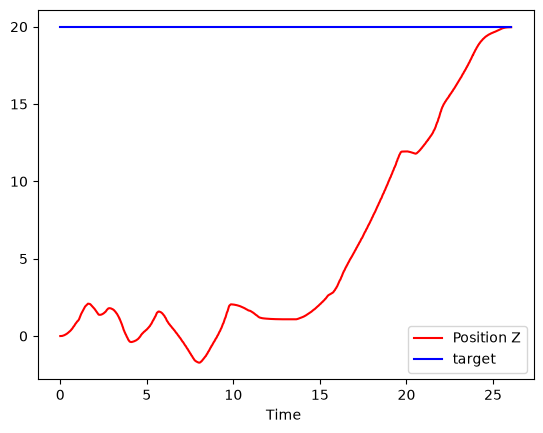

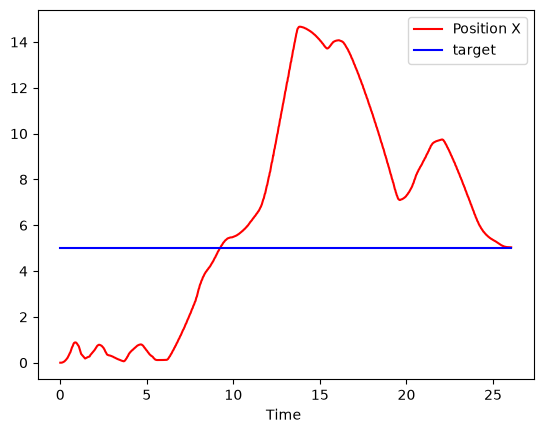

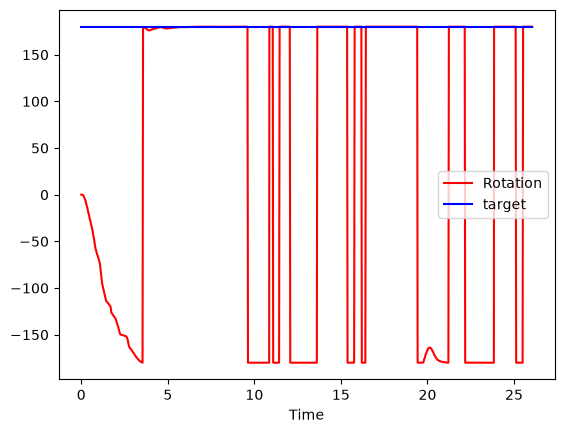

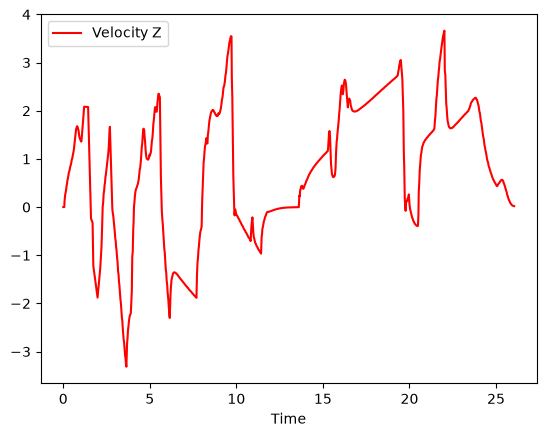

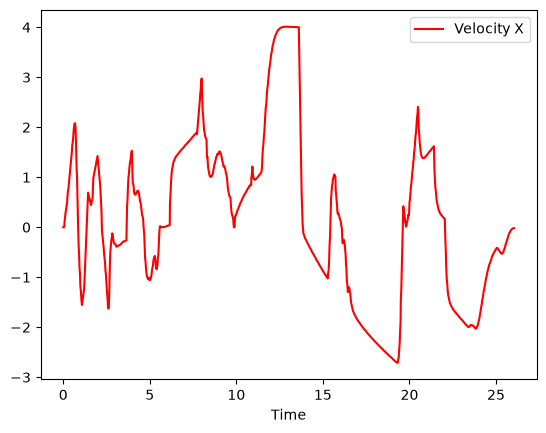

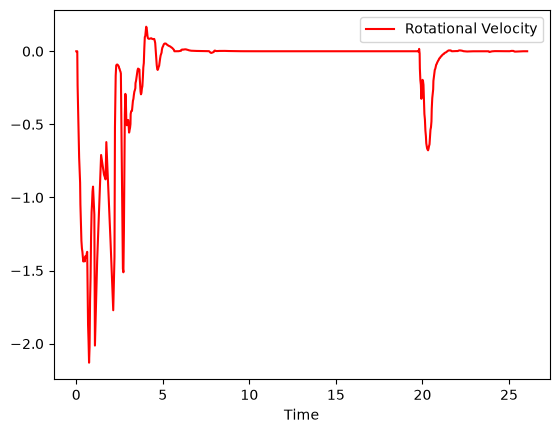

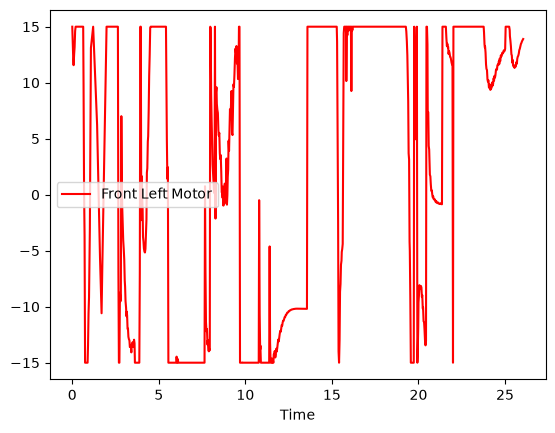

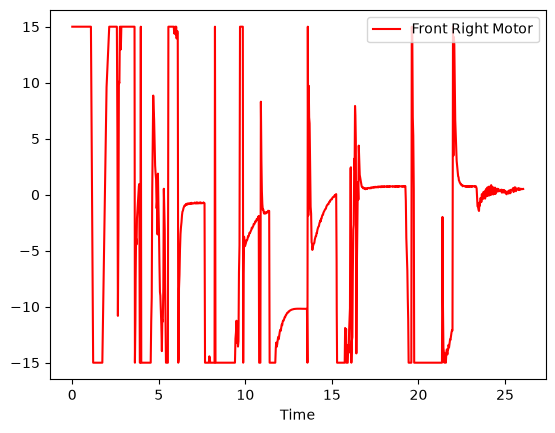

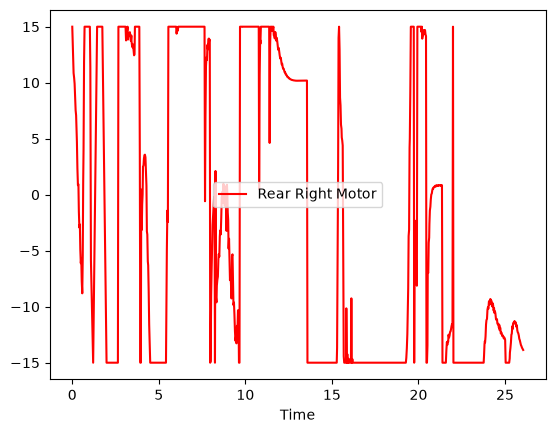

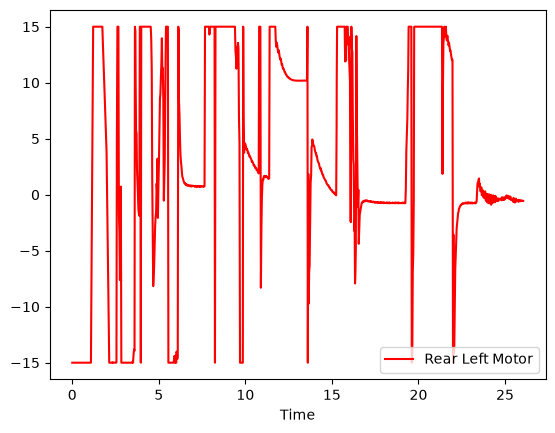

In [53]:
#print plots

for p in plts:
    p.plot()